# 2025년 07월 16일 수요일 (58일차)  


# 📜 목차  
- 회귀평가지표  
- 한글 차트  
- 이진분류 평가지수  
- 차트  
- 인터렉티브  
- 텍스트 분석  
    - 영화 학습 1  
    - 네이버 영화  



<br><br><br>

## 🟢 회귀평가지표  

--- 캘리포니아 집값 회귀 분석 및 평가 예제 시작 ---
<class 'sklearn.utils._bunch.Bunch'>
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
5    2.697
6    2.992
7    2.414
8    2.267
9    2.611
Name: houseval, dtype: float64
mae:평균절대오차 0.5353166913867701
mse:평균제곱오차 0.5388649914036734
mse:평균제곱근오차 0.7340742410708017
결정계수 :  0.58878

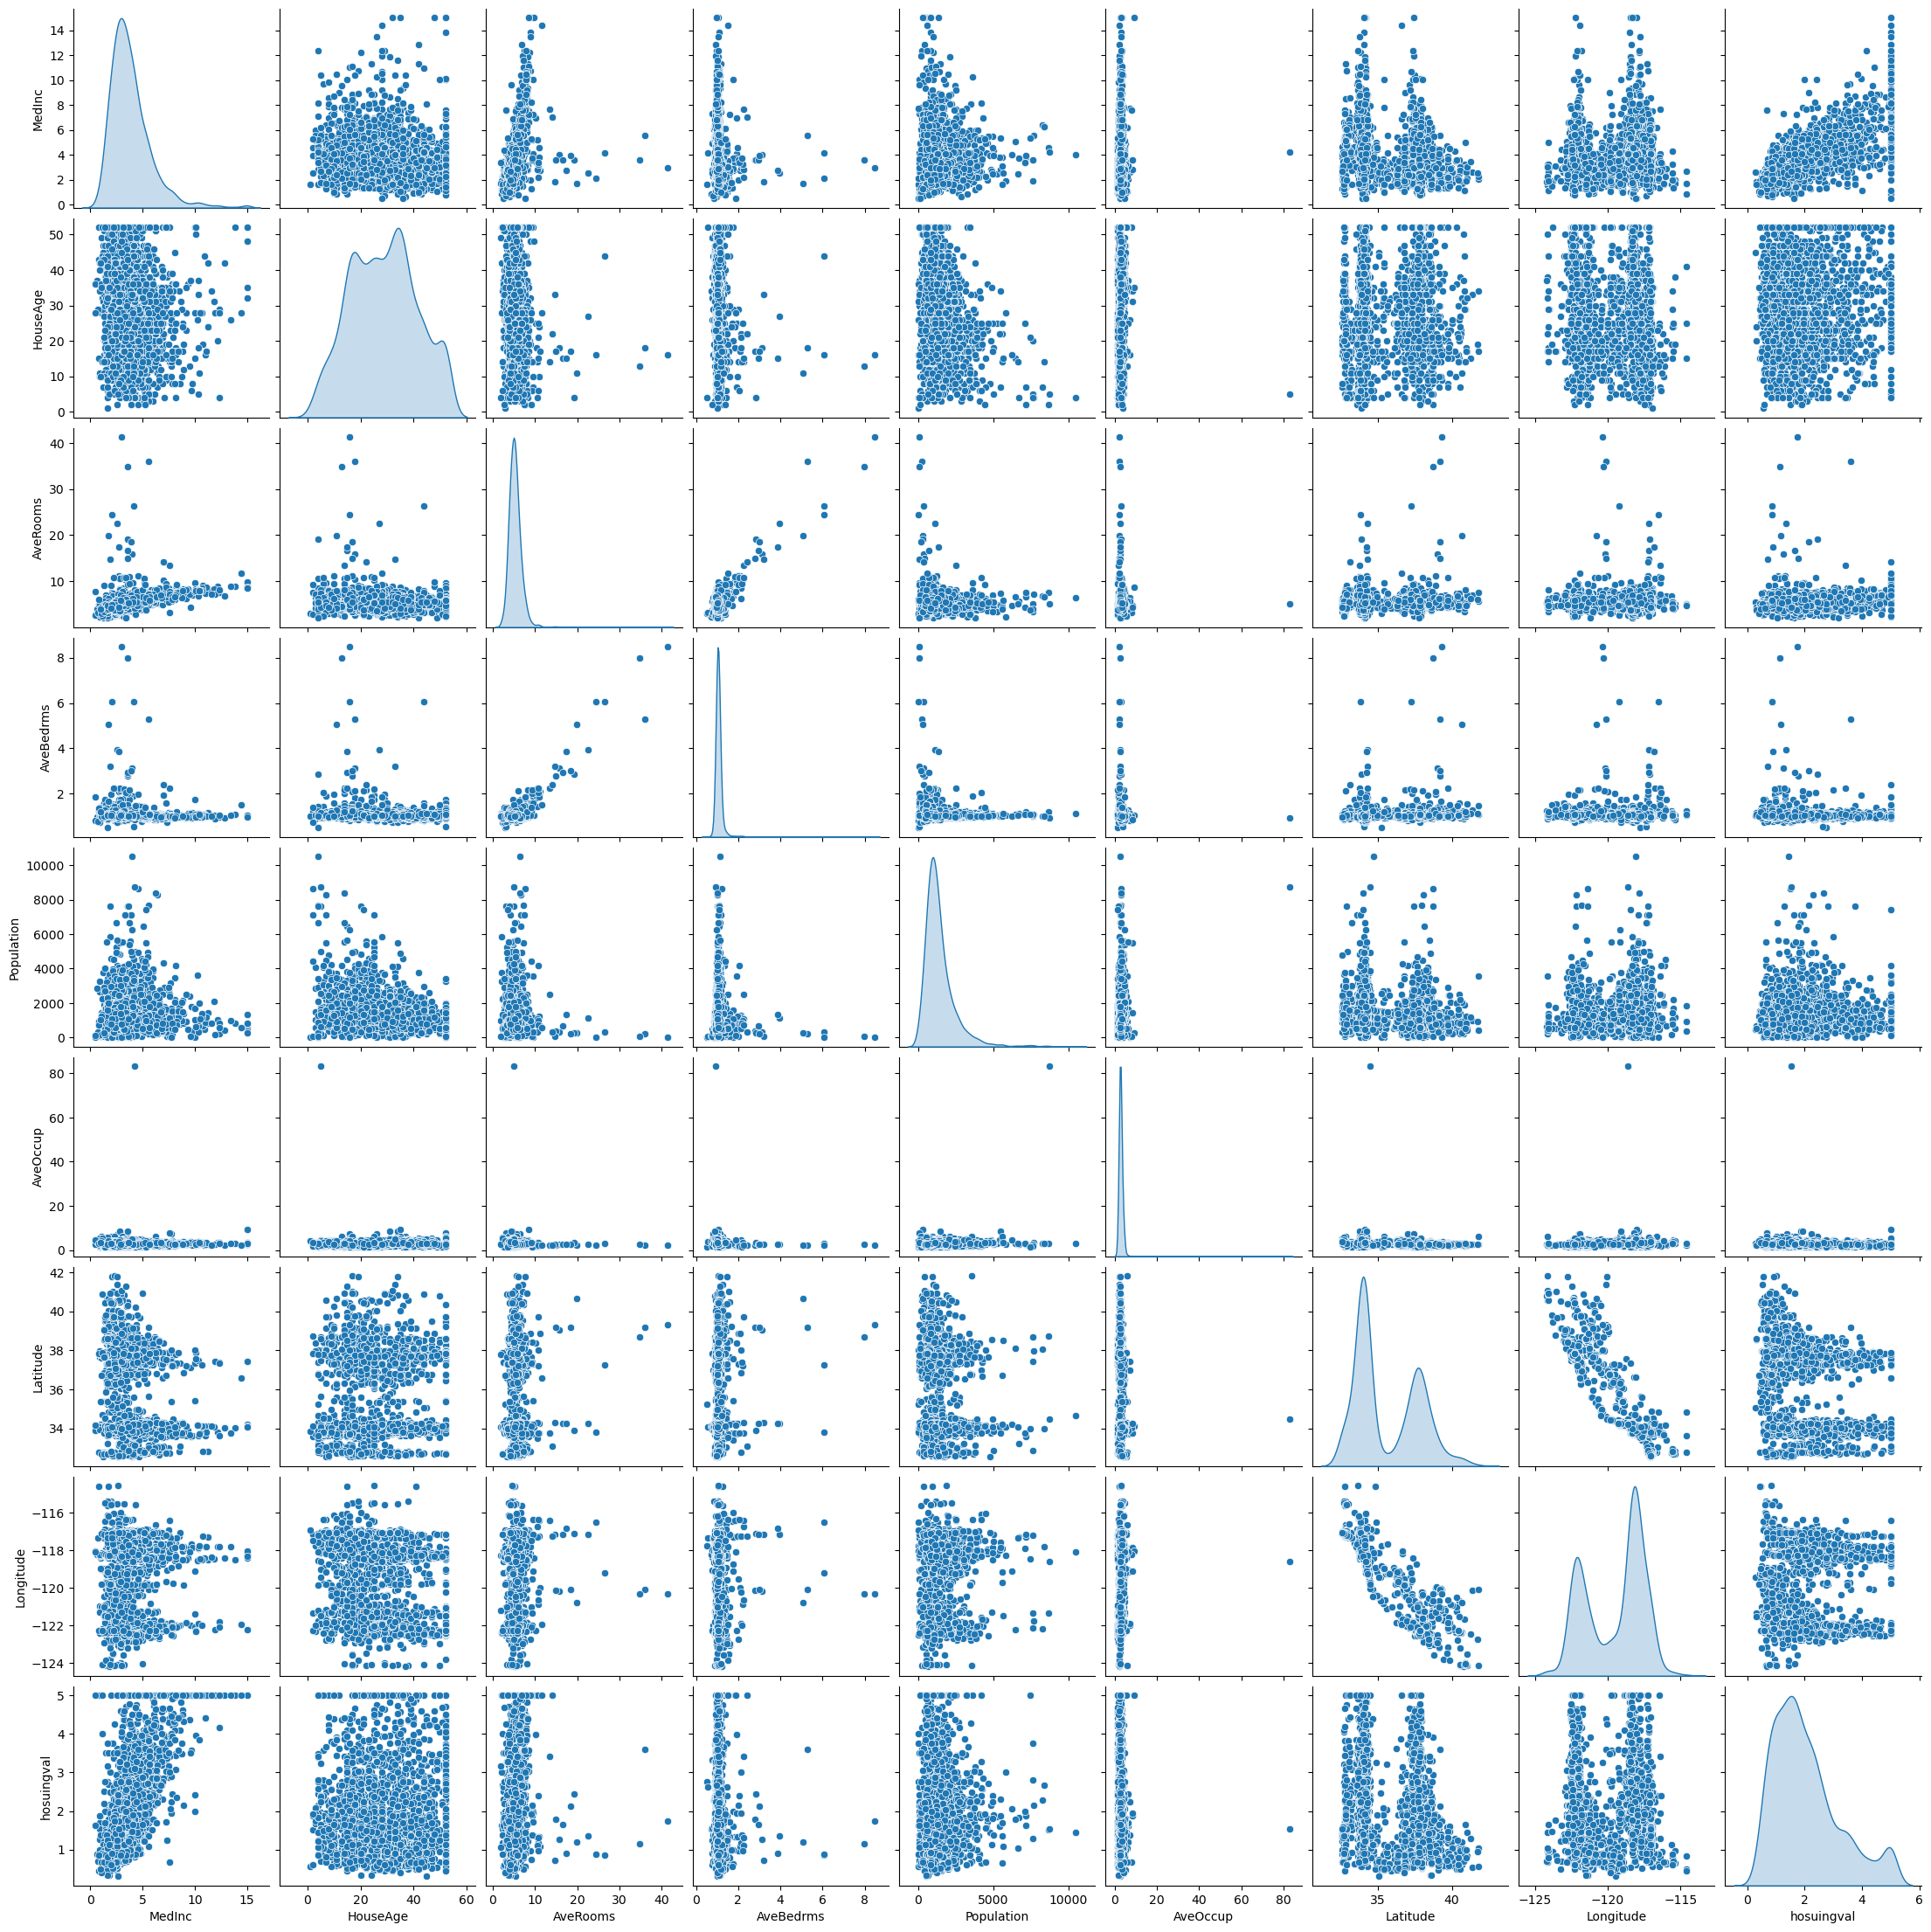

In [ ]:

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing # 캘리포니아 집값 데이터셋
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # 특성 스케일링 (선형 모델에 중요)

print("--- 캘리포니아 집값 회귀 분석 및 평가 예제 시작 ---")

# 1. 캘리포니아 집값 데이터셋 로드
housing = fetch_california_housing()
print(type(housing)) #딥러닝(Tensorflow:c++)->케라스(초보자용),파이토치(세밀하게 제어가 가능하다)

#차트그리려면 numpy -> 요소 하나씩 그려야 해서 차트를 그리고싶다. 
#DataFrame :데이타프레임 자체가 차트를 제공하기도 하고 seaborn 차트 , plotly차트(interactive차트)
#python 코드로 차트를 그리면 plotly 는 html과 css와 자바스크립트로 움직이는 차트가 만들어진다. 
#예전에는 R언어만 지원했는데 현재 Python 라이브러리가 지원을 하고 있다  
#넘파이배열, 컬럼명 
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="houseval") 

print(X.head())
print(X.columns)
print(y[:10])

#1.훈련셋 쪼개기 - numpy 2차원(dataframe), 1차원(series),
X_train, X_test ,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2.결측치,이상치 없음 
#3.스케일링 또는 표준화 정규화
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) #비지도학습 fit -> transform  
X_test_scaled = scaler.fit_transform(X_test)  

#4.선형회귀모델학습
model = LinearRegression() 
model.fit(X_train_scaled, y_train)

#5.테스트데이터로 예측하기 
y_pred = model.predict(X_test_scaled)

#6.회귀모델 평가지표    -    실제값, 기대값=예측값        
mae = mean_absolute_error(y_test, y_pred)
print("mae:평균절대오차", mae)

mse = mean_squared_error(y_test, y_pred)
print("mse:평균제곱오차", mse)

rmse = np.sqrt(mse)
print("mse:평균제곱근오차", rmse)

#결정계수가 1에 가까울 수록 좋다. 다만 특성의 개수가 많아지면 결정계수값이 예측력하고 상관없이 좋아진다. 
#특성이 많아질경우에는 mae나 mse를 쓰자. mse가 이상치에 영향을 많이 받는다 
 
r2 = r2_score(y_test, y_pred) #결정계수, 평상시 score 함수와 동일 
print("결정계수 : ", r2)

print("모델의 score ", model.score(X_test_scaled, y_test))

#차트를 그릴려고 -> 특성이 몇개 안되서 산포도행렬을 그릴려고, 데이터 개수자체가 너무 많아도 문제가 된다.  

print("데이터개수")
print(X.shape)

X["hosuingval"] = y 
print(X.head())
#데이터가 2만개가 넘는다. 차트를 그려보고 , 데이터샘플링 
df_sample = X.sample(n=2000, random_state=42) #데이터를 원하는 만큼 샘플링을 해온다
print(df_sample.shape)

import matplotlib.pyplot as plt 
import seaborn as sns 
sns.pairplot(df_sample, 
             diag_kind='kde',  #대각선 히스트그램 밀도 부드럽게
             kind='scatter')
plt.show() 


<br><br>

## 🟢 차트 한글화  

- 차트에 한글화 지원하기  
    - 폰트를 바꿔야 합니다.  

['STIXSizeOneSym', 'DejaVu Sans Mono', 'cmtt10', 'STIXNonUnicode', 'DejaVu Sans Mono', 'STIXGeneral', 'DejaVu Serif', 'STIXSizeTwoSym', 'cmb10', 'DejaVu Serif', 'STIXSizeTwoSym', 'STIXSizeFourSym', 'STIXSizeFiveSym', 'cmex10', 'STIXNonUnicode', 'STIXSizeThreeSym', 'cmsy10', 'DejaVu Sans', 'cmss10', 'DejaVu Sans Display', 'cmr10', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeOneSym', 'STIXNonUnicode', 'STIXGeneral', 'DejaVu Serif Display', 'DejaVu Sans', 'DejaVu Sans', 'STIXSizeFourSym', 'DejaVu Serif', 'DejaVu Sans Mono', 'STIXGeneral', 'STIXSizeThreeSym', 'cmmi10', 'DejaVu Serif', 'DejaVu Sans', 'DejaVu Sans Mono', 'STHeiti', 'Toppan Bunkyu Midashi Gothic', 'Hannotate SC', 'Charter', 'Libian SC', 'Noto Sans Rejang', 'Times New Roman', 'Weibei TC', 'Osaka', 'Kannada Sangam MN', 'DIN Condensed', '.New York', 'Menlo', 'STIXGeneral', 'Noto Sans Warang Citi', 'Nadeem', 'Kai', 'Apple Braille', 'Times New Roman', 'Hiragino Sans', 'PT Sans', 'HanziPen SC', 'STIXSizeFourSym', 'Baskerville', 'Aria

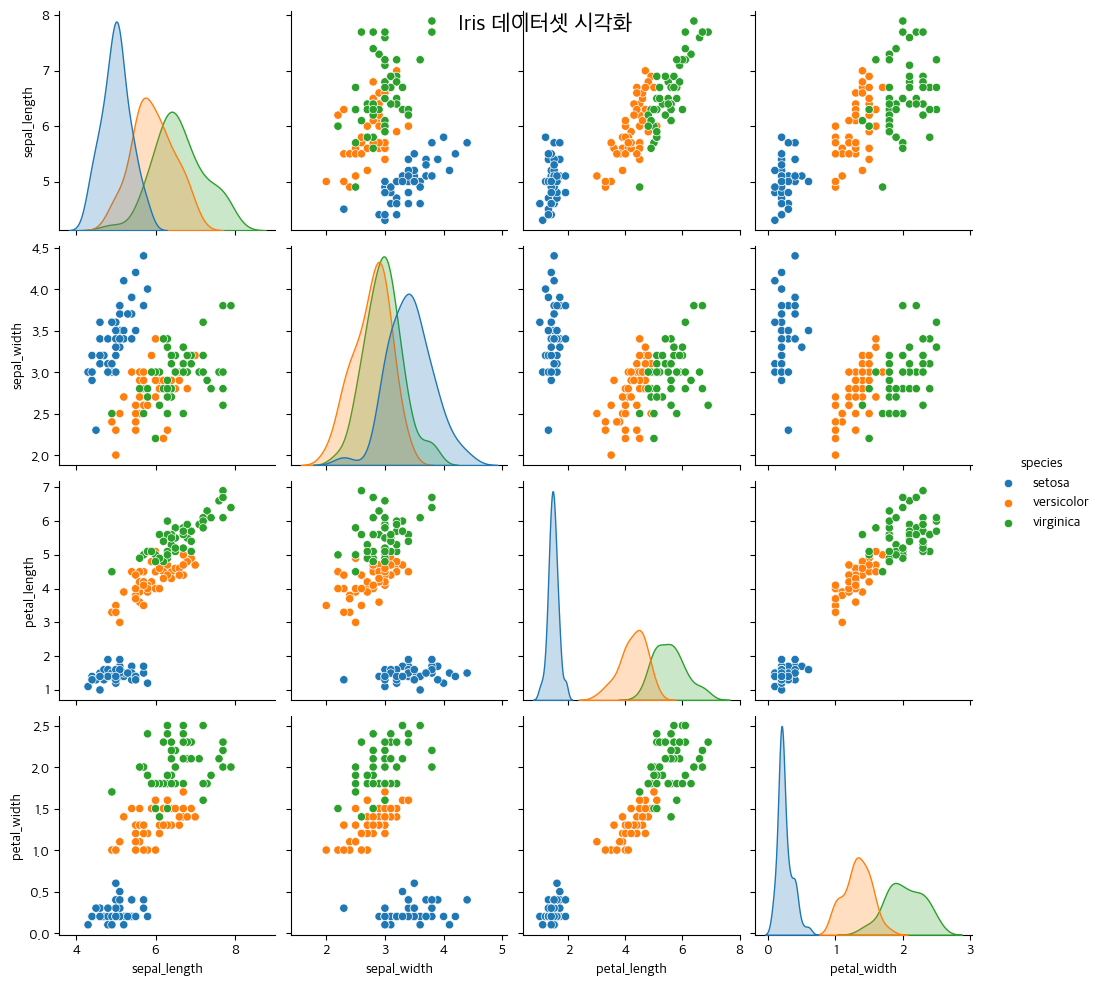

In [3]:
import matplotlib.pyplot as plt


# =======================================================
# 내 컴퓨터에 설치된 한글 글꼴을 알아보자!!!
import matplotlib.font_manager as fm  # 🔥 폰트 관리자
# 글꼴도 ttf방식 - true type 글꼴, 트루타입글꼴 이전에는 비트맵방식
# 글꼴을 확대하면 계단 모양이 나옴 => 백터방식전환 - true type 글꼴
# fm.fontManager.ttflist

# 폰트 목록 출력
font_list = [font.name for font in fm.fontManager.ttflist]
print(font_list)

# 폰트 결정 
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'   # 반드시 한글이 되는 폰트를 사용해야 한다.
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')
sns.pairplot(iris, hue = 'species')
plt.suptitle('Iris 데이터셋 시각화', fontsize = 16)
plt.show()




<br><br>

## 🟢 이진분류 평가지수  

체인지전
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
체인지후
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
{np.int64(0): np.int64(357), np.int64(1): np.int64(212)}
오차행렬
[[86  2]
 [ 3 52]]
              precision    recall  f1-score   support

          양성       0.97      0.98      0.97        88
          악성       0.96      0.95      0.95        55

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



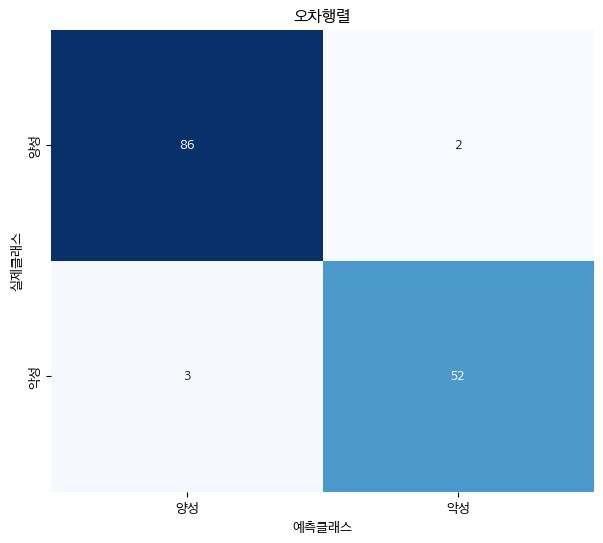

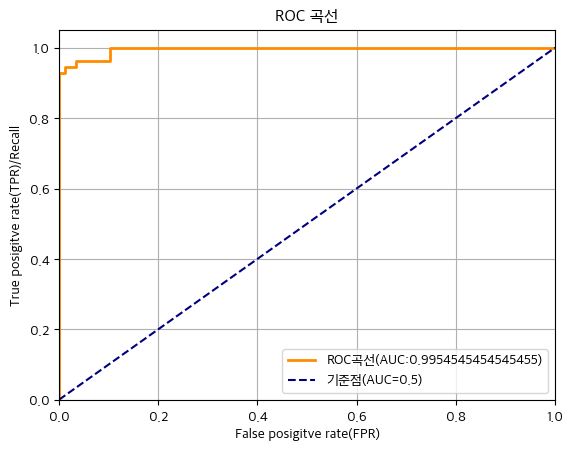

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer # 유방암 데이터셋
from sklearn.preprocessing import StandardScaler # 데이터 스케일링

import matplotlib.pyplot as plt
import seaborn as sns # Seaborn 라이브러리 임포트

plt.rcParams['font.family'] = 'Apple SD Gothic Neo' # 설치된 나눔고딕 폰트 이름으로 변경
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

cancer = load_breast_cancer() 
X = pd.DataFrame(cancer.data, columns= cancer.feature_names)
y = cancer.target #0:악성, 1:음성 
#평가할때 양성기준 - 필요해서 붙인거  악성-> 양성(1)로 보는 판단하기 편하다. 악성, 음성을 서로 바꾸자 
y_changed = np.where(y==0, 1, 0)    #numpy에 where 조건식을 만족하면 (조건식, 값1, 값2)
                                    #조건식을 만족하면 값1, 만족하지 않으면 값2를 반환 
print("체인지전")
print(y[:20])
print("체인지후")
print(y_changed[:20])

#데이터가 불균형셋인지 확인해보자 
print( dict(zip(*np.unique(y_changed, return_counts=True))))

#데이터 쪼개기 
X_train, X_test, y_train, y_test = train_test_split(X, y_changed, random_state=1)

#특성스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#학습
model = LogisticRegression(random_state=1, solver='liblinear')
model.fit(X_train_scaled, y_train)

#예측값 가져오기 
y_pred = model.predict(X_test_scaled)
#양성예측한것만 가져오기, 악성에 대한 예측 확률 하나만 가져오기  
y_pred_proba = model.predict_proba(X_test_scaled)[:,1] 

#오차행렬 구하기 
cm = confusion_matrix(y_test, y_pred)
print("오차행렬")
print(cm)

#분류리포트 
report = classification_report(y_test, y_pred, target_names=['양성', '악성'])
print(report)

#seaborn 차트를 이용한 시각화 
plt.figure( figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['양성', '악성'],
            yticklabels=['양성', '악성'] )
plt.xlabel('예측클래스')
plt.ylabel('실제클래스')
plt.title('오차행렬')
plt.show() 

#ROC곡선  roc_curve 함수가 3개의 반환값을 준다 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC곡선(AUC:{auc_score})')
plt.plot([0,1], [0,1], color='navy', linestyle='--', label='기준점(AUC=0.5)')
plt.xlim([0.0, 1.0]) #눈금 범위 
plt.ylim([0.0, 1.05]) #눈금범위 
plt.xlabel('False posigitve rate(FPR)')
plt.ylabel('True posigitve rate(TPR)/Recall')
plt.title("ROC 곡선")
plt.legend(loc="lower right") #범주는 오른쪽 하단에
plt.grid(True) #격자선 그리기 
plt.show()

#roc곡선 아래의 영역을 auc 라고 부르고, 1에 가까울 수록 좋다  


<br><br>

## 🟢 차트  

### 🟡 차트 라이브러리  

### 1. 파이썬으로 사용 가능한 차트  
- **Matplotlib** : 가장 기본 연필, 종이·연필 느낌  
- **Seaborn** : Matplotlib에 예쁜 무늬를 입힌 크레파스  
- **Plotly** : 손가락으로 움직일 수 있는 전자칠판  
    - [참고] https://wikidocs.net/185024  
- Bokeh : 웹으로 바로 보여 주는 물감 세트  
- Altair : “규칙만 말해 줘, 그림은 내가 알아서” 스타일  
- pandas 내장 plot : 엑셀처럼 바로 그려 주는 미니 연필  
- ggplot(plotnine) : R의 ggplot2 맛을 파이썬에 옮긴 것  
- Pygal : SVG(벡터) 그림을 뚝딱 만드는 가벼운 연필  
- Holoviews / hvPlot : 데이터만 주면 자동으로 알맞은 그림 추천  
- VisPy : 3D·게임처럼 빠른 GPU 그림 전용  
- Geoplot / Cartopy : 지도를 색칠하기 좋은 지도 전용 색연필  
- Chartify : 우버(Uber)가 만든 “쉽게 예쁜 차트” 도구  

### 2. 자바스크립트(웹)로 사용가능한 차트  
- **D3.js** : 레고 블록처럼 기본 조각을 조립해서 만드는 만능 키트  
- **Chart.js** : 몇 줄이면 막대·선·파이 다 완성되는 간단 키트  
- ECharts : 중국 Baidu가 만든 화려한 불꽃놀이 세트  
- Highcharts : 기업용 기능이 풍부한 고급 세트  
- ApexCharts / Recharts / Nivo / Victory : React와 잘 어울리는 친구들  
- Google Charts : 구글이 제공하는 웹 차트 도구  
- Vega / Vega-Lite : “데이터 설명서”만 주면 자동 완성  
- Plotly.js : 파이썬 Plotly의 웹 엔진 버전  

findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font family 'Nanum AInMamSonGeurSsi' not found.
findfont: Font

Nanum AInMamSonGeurSsi


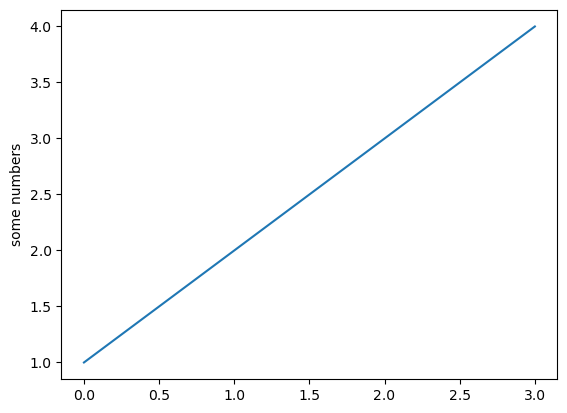

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager as fm
from matplotlib import font_manager, rc

# 절대경로지정 (windows 기준)
# font_name = font_manager.FontProperties(fname = 'C:/Windows/Fonts/malgun.ttf').get_name()

# 상대경로지정
font_name = font_manager.FontProperties(fname = "fonts/Nanum AInMamSonGeurSsi.ttf").get_name()
print(font_name)
plt.rcParams['font.family'] = font_name      # 이것만 설정한다면 된다고 합니다.
plt.rcParams['axes.unicode_minus'] = False   # 눈금에서 한글깨짐 문제 발생

# 차트 그리기
plt.plot([1, 2, 3, 4])
plt.ylabel('some numbers')
plt.show()


<br><br>

## 🟢 인터렉티브  

인터렉티브(Interactive)는 사람이 컴퓨터나 기기와 서로 대화하듯 정보를 주고받을 수 있는 방식을 말해요.  

#### AI 데이터사이언티스트와 인터렉티브  

- AI 데이터사이언티스트가 되면, 인터렉티브한 데이터 시각화 도구를 만들 수 있어요.  
    - 사용자가 버튼을 클릭하면 다른 그래프로 바뀌는 대시보드  
    - 마우스를 가져다 대면 자세한 정보가 나타나는 차트  
    - 사용자의 질문에 따라 다른 분석 결과를 보여주는 AI 시스템  

인터렉티브는 마치 컴퓨터와 대화를 나누는 것처럼 서로 정보를 주고받는 거예요. 이렇게 하면 사용자가 더 쉽고 재미있게 정보를 이해할 수 있답니다.  

<br><br>

## 🟢 텍스트 분석  

- 데이터를 가지고 직접 분석해보기  
    - 데이터: 로이터 뉴스, IMDB 영화평론 사이트  
    - 1. 토큰화 -> 토큰을 나눈다. 단어로 나눈다. 바꿔서 처리가 가능핟.  
    - 2. 어휘사전 구축 ->  단어한테 고유 숫자를 준다.   
        - I like star  =>  I:0   like:2   star:2  
        - 어휘 사전이 충분히 커야 한다.  
    - 3. 단어 빈도 수 계산   like:10, star:20, red:4 ......  
    - 4. 문서단어 행렬 => 단어 빈도수를 행렬로 표현한다. 0이 엄청 많다. 희소행렬이라고 한다.  

<br><br>

### 🟡 영화 학습  

- aclImdb 데이터셋를 활용하여 실습을 해볼 것입니다.  

#### ⚫️  한눈에 보기  
aclImdb는 “영화 후기 모음집”으로, 인공지능에게 “이 후기가 기분 좋은 글인지, 나쁜 글인지”를 가르칠 때 많이 쓰는 유명한 연습용 데이터 세트입니다.  


#### ⚫️  왜 중요할까요?  
마치 초등학생이 동화책을 읽으며 “이 동화는 행복한 이야기야, 슬픈 이야기야”를 구분해 보는 것처럼, 컴퓨터도 글의 분위기를 알아야 말을 이해하고 똑똑해집니다. aclImdb는 바로 그 연습 문제집 역할을 합니다.  


#### ⚫️  안에 뭐가 들어 있을까요?  
1. 영화 리뷰 글 50,000개  
2. 각 글에는 “긍정(좋아요)” 또는 “부정(싫어요)” 딱지가 붙어 있음  
3. 훈련용·시험용 폴더가 따로 있어서,  
   - 훈련용(train) 25,000개  
   - 시험용(test) 25,000개  
4. 모든 글은 .txt 파일로 저장됨  


#### ⚫️  비유로 쉽게 이해하기  
- 편지 상자 두 개가 있습니다.  
  - 빨간 상자: “이 영화 최고야!” 같은 기분 좋은 편지  
  - 파란 상자: “이 영화 별로야…” 같은 기분 나쁜 편지  
- 컴퓨터에게 두 상자의 편지를 잔뜩 읽혀서,  
  - 새 편지를 보여주면 “이건 빨간 상자 편지구나!” 하고 맞히도록 훈련하는 것,  
  - 그때 쓰는 ‘편지 뭉치’가 바로 aclImdb입니다.  


#### ⚫️  어디에 쓰이나요?  
- 감정 분석(긍·부정 분류) 모델 만들기  
- 자연어 처리(NLP) 연구 논문·대회 예시 데이터  
- 딥러닝 기초 실습용 과제  


#### ⚫️  여러분이 AI 데이터사이언티스트가 되기 위한 첫걸음  
1. 글을 열어 직접 읽어 보세요. “아, 이런 식으로 긍정·부정을 구분하는구나” 감을 잡을 수 있습니다.  
2. 데이터가 폴더로 잘 정리돼 있으므로, 파일 구조를 눈으로 확인하면 데이터 탐색(EDA) 연습이 됩니다.  
3. 이후 파이썬으로 간단히 불러와 모델을 돌려 보면, “데이터 → 모델 → 결과” 흐름을 체험할 수 있습니다.  


#### ⚫️  기억하면 좋은 포인트  
- 이름에서 ‘acl’은 학회(ACL: Association for Computational Linguistics)에 발표됐다는 뜻, ‘Imdb’는 영화 리뷰 사이트 IMDb에서 가져왔다는 뜻입니다.  
- 텍스트만 있으므로, 이미지나 숫자보다 파일 크기가 작아 연습하기 부담이 적습니다.  
- 처음 공부하실 때, 글이 영어라서 막막할 수 있지만 “긍정·부정 딱지”만 잘 활용해도 모델은 충분히 배웁니다.  


#### ⚫️  마무리 한 줄  
aclImdb는 “컴퓨터에게 영화 후기의 기분을 맞히게 만드는 초·중급 레벨의 필수 연습장”이라고 생각하시면 됩니다.  

In [9]:
###############################################################################
# 0. 도구 챙기기
#    - 어떤 일을 하려면 연필, 지우개, 공책이 필요하듯
#      파이썬에서도 라이브러리를 먼저 불러옵니다.
###############################################################################
from sklearn.datasets import load_files           # 우체통에서 편지를 한웅큼 꺼내는 집게
import pandas as pd                               # 편지를 표(엑셀처럼)로 붙여 주는 풀
import numpy as np                                # 숫자 계산용 자와 계산기 (이번 예시는 거의 안 씀)
from sklearn.feature_extraction.text import CountVectorizer  # 단어를 세어 주는 손가락 셈 도구
from sklearn.linear_model import LogisticRegression           # 편지 내용으로 ‘좋아요/싫어요’를 맞히는 선생님

###############################################################################
# 1. 편지 꺼내기
###############################################################################
# aclImdb/train 폴더 안에는
#   pos/  → “좋아요” 편지
#   neg/  → “싫어요” 편지
# 가 폴더별로 담겨 있습니다.
reviews_train = load_files('data/aclImdb/train')
print(reviews_train.keys)   # {'data', 'target', ...} 같은 구성 확인

# reviews_train.data  : 편지(리뷰)가 바이트 문자열 형태로 들어 있음
# reviews_train.target: 각 편지의 답(1=긍정, 0=부정)
text_train = reviews_train.data
y_train    = reviews_train.target

###############################################################################
# 2. 편지를 공책(표)으로 정리하기
###############################################################################
# 첫 번째 열 : 편지 내용
# 두 번째 열 : 답(좋아요/싫어요)
df = pd.DataFrame(text_train, columns=['review'])  # 열 이름을 'review'로 지정
df['target'] = y_train                             # 새 열 추가

# 공책을 CSV 파일로 저장 (utf-8-sig: 엑셀에서 한글 안 깨지게)
df.to_csv('imdb.csv', encoding='utf-8-sig', index=False)

print(df.head())   # 위에서 5줄 미리 보기

###############################################################################
# 3. 편지 내용 청소하기  ― “<br />” 같은 HTML 표식은 스티커 제거하듯 떼어냅니다.
###############################################################################
# text_train 안 자료는 b'...' 처럼 바이트 문자열입니다.
# 바이트 문자열에서도 replace를 쓸 수 있으니 <br /> 를 빈 문자열로 치환합니다.
text_train = [review.replace(b"<br />", b"") for review in text_train]

###############################################################################
# 4. 단어 세기 : CountVectorizer
###############################################################################
# (1) fit : 모든 편지를 훑어보며 “사전”을 만듭니다.
# (2) transform : 각각의 편지를 “단어 개수 표”로 바꿔 줍니다.
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)

# 사전에 몇 개 단어가 들어갔는지 확인해 봅니다.
feature_names = vect.get_feature_names_out()
print(f"\n특성(단어) 총 개수 : {len(feature_names)}")
print(f"앞에서 20개 단어 : {feature_names[:20]}")

###############################################################################
# 5. 모델 학습 : LogisticRegression
###############################################################################
# 선생님(모델)에게
#   X_train : 단어 개수 표
#   y_train : 답(0/1)
# 을 보여 주며 학습시킵니다.
model = LogisticRegression(max_iter=1000)  # 반복 횟수를 넉넉히 설정
model.fit(X_train, y_train)

# 훈련 데이터에 대해 맞힌 비율(정확도)을 확인합니다.
train_score = model.score(X_train, y_train)
print(f"\n훈련 데이터 정확도 : {train_score:.3f}")

<built-in method keys of Bunch object at 0x111defe30>
                                              review  target
0  b'I caught this film at the Edinburgh Film Fes...       0
1  b"Based upon the recommendation of a friend, m...       0
2  b'This is not an entirely bad movie. The plot ...       0
3  b"I must confess to not having read the origin...       1
4  b"as the title of this post says, the section ...       2

특성(단어) 총 개수 : 43737
앞에서 20개 단어 : ['00' '000' '000000003' '00001' '000s' '001' '007' '0079' '0080' '0083'
 '00am' '00pm' '00s' '01' '02' '03' '04' '05' '06' '06th']

훈련 데이터 정확도 : 1.000


<br>

### 🟡 네이버 영화  

In [2]:
from sklearn.datasets import load_files 
import pandas as pd 
import numpy as np 
from sklearn.feature_extraction.text import CountVectorizer 
import matplotlib.pyplot as plt 
import re #정규식 처리 하는 라이브러리 

#파일을 읽는다 - 구분자가 탭키다 
#keep_default_na - NaN 값을 None으로 바꾼다
df_train = pd.read_csv("data/aclImdb/ratings_train.txt", delimiter="\t", keep_default_na=False)
print( df_train.head() )
text_train, y_train = df_train["document"].values, df_train["label"].values
print( text_train[:3])
print( y_train[:3])

#text_traind을 벡터화하자 

from konlpy.tag import Okt  #현재 가장 많이 사용하는 형태소 분리 알고리즘 
okt = Okt() 
stop_words = ["아", "..", "?", "있는" ]
def okt_tokenizer(text):
    #특수문자를 제거하기 (한글, 숫자, 영어, \s - 공백  )
    # 정규식 패턴을 사용해서 문자 바꿔치기
    text = re.sub(r"[^\uAC00-\uD7A3\s]", "", text)
    temp = okt.morphs(text)
    #제거할거 있으면 제거시켜서 보내기, 불필요한 단어나 한글자는 삭제시키고 나머지만 
    temp = [word for word in temp if word not in stop_words and len(word)>=2]
    return temp 

for i in range(0, 10):
    print( okt_tokenizer(text_train[i] ))

#CountVectorizer의 tokenizer 매개변수에 우리가 토큰나이저 만들어서 주면된다. 
#한글 토큰나이저로 바꿔치기를 한다. 경고는 무시해도 된다. 
vect = CountVectorizer(tokenizer=okt_tokenizer).fit(text_train)

feature_names = vect.get_feature_names_out() 
print("특성의 개수 ", len(feature_names))
print(feature_names[:20])

X_train = vect.transform(text_train)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
print( model.score(X_train, y_train))


         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      1
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
['아 더빙.. 진짜 짜증나네요 목소리' '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나'
 '너무재밓었다그래서보는것을추천한다']
[0 1 1]


['더빙', '진짜', '짜증나네요', '목소리']
['포스터', '보고', '초딩', '영화', '오버', '연기', '조차', '가볍지', '않구나']
['무재', '밓었', '다그', '래서', '보는것을', '추천']
['교도소', '이야기', '구먼', '솔직히', '재미', '없다', '평점', '조정']
['사이', '몬페', '익살스런', '연기', '돋보였던', '영화', '스파이더맨', '에서', '늙어', '보이기만', '했던', '커스틴', '던스트', '너무나도', '이뻐', '보였다']
['걸음', '부터', '초등학교', '학년', '생인', '살용', '영화', '반개', '아까']
['원작', '긴장감', '제대로', '살려내지못', '했다']
['반개', '아깝다', '나온다', '이응경', '길용우', '생활', '인지', '정말', '해도', '그것', '보단', '낫겟다', '납치', '감금', '반복', '반복', '드라마', '가족', '없다', '연기', '하는', '사람']
['액션', '없는데도', '재미', '안되는', '영화']
['왜케', '평점', '낮은건데', '헐리우드', '화려함에만', '너무', '길들여져', '있나']


/opt/anaconda3/envs/aiBootCamp/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


특성의 개수  17281
['가가' '가감' '가게' '가격' '가고' '가고싶으면' '가고싶을' '가관' '가구' '가구야' '가기' '가까운'
 '가까웠을텐데' '가까이' '가깝다' '가끔' '가나' '가나다' '가나다라' '가난']
0.9648316142661861
